# Temperature measurement of quantum chips

Try found possible way to measure temperature on chip.
The basic idea is to design proper quantum bit to reveal temperature changes.

In [1]:
from typing import (
    Any,
    Union,
    Iterable,
    Tuple,
)


In [2]:
import numpy as np
import pandas as pd
import scipy as sp
from scipy import constants
from matplotlib.figure import Figure
import matplotlib.pylab as plt

print(f'Import numpy V{np.__version__}')
print(f'Import pandas V{pd.__version__}')
print(f'Import scipy V{sp.__version__}')


Import numpy V1.23.5
Import pandas V1.4.3
Import scipy V1.10.1


## Prepare posibility function

In [3]:
def possibility_thermal_excitation(
        freq_excitation: Union[float, np.ndarray],
        temperature: Union[float, np.ndarray]
) -> Union[float, np.ndarray]:
    if isinstance(freq_excitation, float) and \
            isinstance(temperature, float) and \
            temperature > 0.0 and freq_excitation > 0.0:
        return 1.0 / \
            (np.exp(constants.h * freq_excitation /
                    constants.Boltzmann / temperature) - 1.0)
    elif isinstance(freq_excitation, np.ndarray) and \
            isinstance(temperature, float) and \
            temperature > 0.0:
        posibility = np.zeros_like(freq_excitation)
        valids = freq_excitation > 0.0
        factor = constants.h / constants.Boltzmann / temperature
        posibility[valids] = 1.0 / \
            (np.exp(freq_excitation[valids] * factor) - 1.0)
        return posibility
    elif isinstance(freq_excitation, float) and \
            isinstance(temperature, np.ndarray) and \
            freq_excitation > 0.0:
        posibility = np.zeros_like(temperature)
        valids = temperature > 0.0
        factor = freq_excitation * constants.h / constants.Boltzmann
        posibility[valids] = 1.0 / \
            (np.exp(factor / temperature[valids]) - 1.0)
        return posibility
    elif isinstance(freq_excitation, np.ndarray) and \
            isinstance(temperature, np.ndarray) and \
            freq_excitation.shape == temperature.shape:
        posibility = np.zeros_like(freq_excitation)
        valids = (freq_excitation > 0.0) & (temperature > 0.0)
        factor = constants.h / constants.Boltzmann
        posibility[valids] = 1.0 / (np.exp(freq_excitation[valids] /
                                           temperature[valids] * factor) - 1.0)
        return posibility
    raise ValueError(f'Invalid input {freq_excitation} and {temperature}')


In [4]:
possibility_thermal_excitation(5.5e9, 60e-3)


0.012438681400911852

In [5]:
def draw_possibility_on_temperature(
        freq_excitaion: float,
        temperatures: np.ndarray
) -> [np.ndarray, Figure]:
    if not isinstance(freq_excitaion, float) or freq_excitaion < 1e-6:
        raise ValueError(f'Invalid frequency {freq_excitaion}')
    if not isinstance(temperatures, np.ndarray):
        raise TypeError(f'Invalid temperature type {type(temperatures)}')
    shape = temperatures.shape
    if len(shape) == 1 or \
            (len(shape) == 2 and (shape[0] == 1 or shape[1] == 1)):
        possibilities = possibility_thermal_excitation(freq_excitaion,
                                                       temperatures)
        fig = plt.figure(figsize=(10, 7))
        plt.xlabel('Temperature (mK)')
        plt.ylabel('Possibility (%)')
        plt.title(f'Frequency: {freq_excitaion * 1e-9}GHz')
        plt.plot(temperatures * 1e3, possibilities * 100.0)
        return possibilities, fig
    raise ValueError(f'Invalid shape of temperatues: {shape}')


## Try normal quantum qubit

In [6]:
temperatures = np.linspace(1e-3, 30e-3, 30, True)
print(f'Prepare temperature sequence: {temperatures}')


Prepare temperature sequence: [0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011 0.012
 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023 0.024
 0.025 0.026 0.027 0.028 0.029 0.03 ]


10mK: 3.120982227319309e-11 %
30mK: 0.0067835946911352476 %


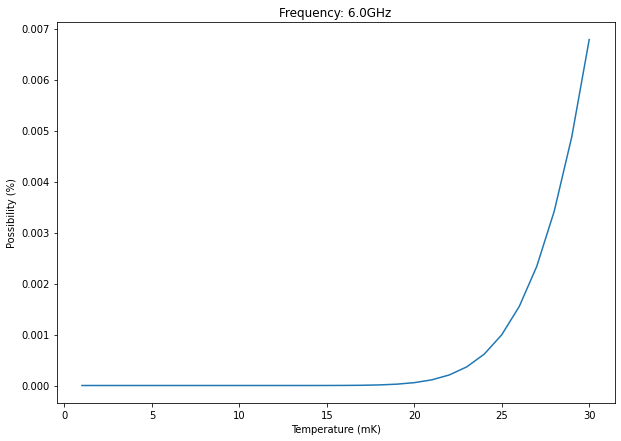

In [7]:
p, _ = draw_possibility_on_temperature(6.0e9, temperatures)
print(f'10mK: {p[9] * 100.0} %')
print(f'30mK: {p[29] * 100.0} %')
plt.show()


10mK: 3.789449114448138e-09 %
30mK: 0.0335998953331063 %


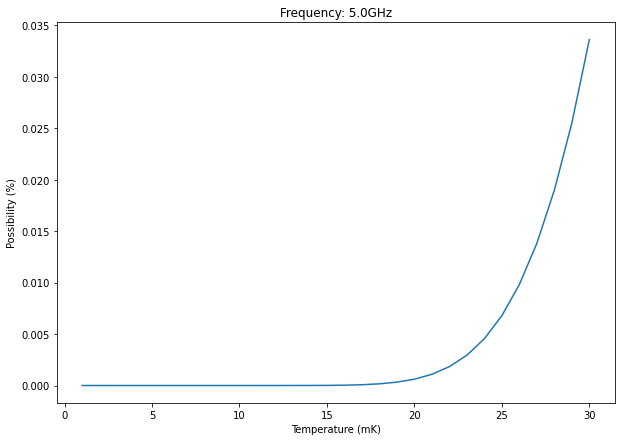

In [8]:
p, _ = draw_possibility_on_temperature(5.0e9, temperatures)
print(f'10mK: {p[9] * 100.0} %')
print(f'30mK: {p[29] * 100.0} %')
plt.show()


## Try to find proper frequency

10mK: 0.830437336423946 %
30mK: 25.30503391370289 %


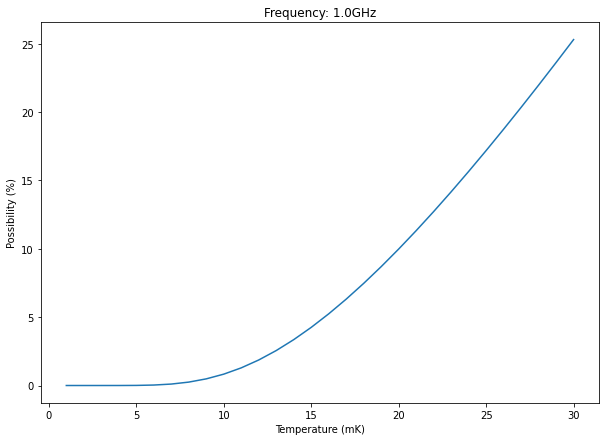

In [9]:
p, _ = draw_possibility_on_temperature(1.0e9, temperatures)
print(f'10mK: {p[9] * 100.0} %')
print(f'30mK: {p[29] * 100.0} %')
plt.show()


10mK: 0.0067835946911352606 %
30mK: 4.251672883564913 %


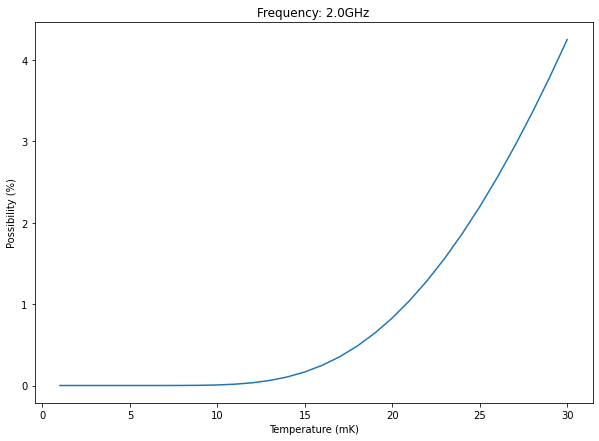

In [10]:
p, _ = draw_possibility_on_temperature(2.0e9, temperatures)
print(f'10mK: {p[9] * 100.0} %')
print(f'30mK: {p[29] * 100.0} %')
plt.show()


10mK: 0.0006155888050717932 %
30mK: 1.866935240074222 %


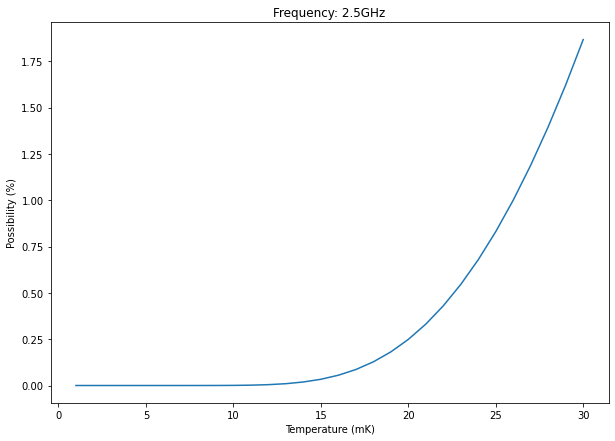

In [11]:
p, _ = draw_possibility_on_temperature(2.5e9, temperatures)
print(f'10mK: {p[9] * 100.0} %')
print(f'30mK: {p[29] * 100.0} %')
plt.show()


10mK: 9.981030749537737 %
30mK: 81.61531834509202 %


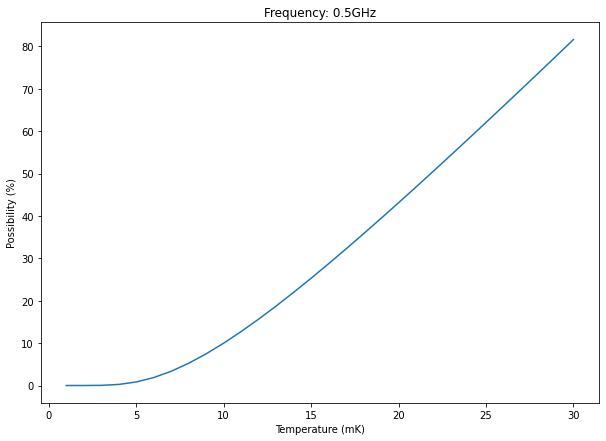

In [12]:
p, _ = draw_possibility_on_temperature(0.5e9, temperatures)
print(f'10mK: {p[9] * 100.0} %')
print(f'30mK: {p[29] * 100.0} %')
plt.show()


## Modification on qubit

Cause $\omega = \sqrt{8 E_j E_c} - E_c$, we have

$$\frac{\partial\omega}{\partial E_c} = \sqrt{\frac{2 E_j}{E_c}} - 1$$

Since $E_j \gg E_c$, we have 

$$\frac{\partial\omega}{\partial E_c} \gg 0$$

Consequently, to decrease $\omega$, it suffices to reduce size of capacity,
which leads to smaller size.

In [13]:
def calc_capacity_ratio(freq_ratio: float):
    sqrt_fc = 10.0 * np.sqrt(2.0) - \
        np.sqrt(200.0 - (20 * np.sqrt(2.0) - 1.0) / 5.0)
    return sqrt_fc * sqrt_fc


In [14]:
calc_capacity_ratio(1.0 / 5.0)


0.03773818249202579

## Prepare for patent

Generate drawings for patent preparation.

In [13]:
def draw_possibility_on_frequencies(
        frequencies: Iterable[Tuple[float, str]]
) -> [pd.DataFrame, Figure]:
    temperatures = np.linspace(5e-3, 30e-3, 26, True)
    rst = pd.DataFrame()
    rst['temperature'] = temperatures
    fig = plt.figure(figsize=(10, 7))
    plt.xlabel('Temperature (mK)')
    plt.ylabel('Possibility (%)')
    for freq, style in frequencies:
        possibilities = possibility_thermal_excitation(freq, temperatures)
        label = f'{freq * 1e-9:.3}GHz'
        plt.plot(temperatures * 1e3, possibilities * 100.0, style, label=label)
        rst[label] = possibilities
    plt.legend()
    return rst, fig


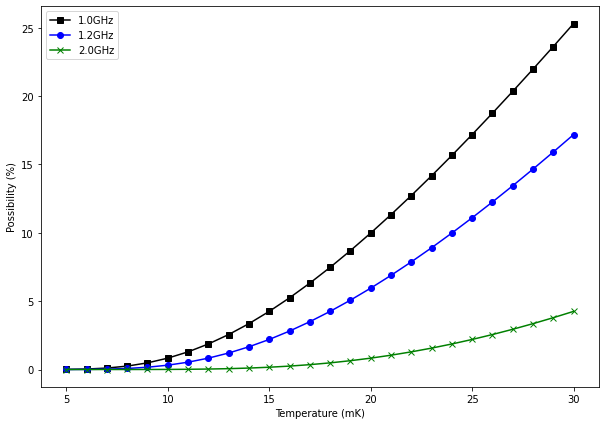

In [14]:
rst, _ = draw_possibility_on_frequencies([(1.0e9, 'k-s'), (1.2e9, 'b-o'), (2.0e9, 'g-x')])
plt.show()


In [15]:
rst


,temperature,1.0GHz,1.2GHz,2.0GHz
0,0.005,0.000068,0.000010,4.601091e-09
1,0.006,0.000336,0.000068,1.128195e-07
2,0.007,0.001054,0.000267,1.108922e-06
3,0.008,0.002487,0.000748,6.155888e-06
4,0.009,0.004855,0.001666,2.334889e-05
5,0.010,0.008304,0.003164,6.783595e-05
6,0.011,0.012905,0.005352,1.623536e-04
7,0.012,0.018669,0.008304,3.359990e-04
8,0.013,0.025566,0.012057,6.218391e-04
9,0.014,0.033539,0.016620,1.054163e-03


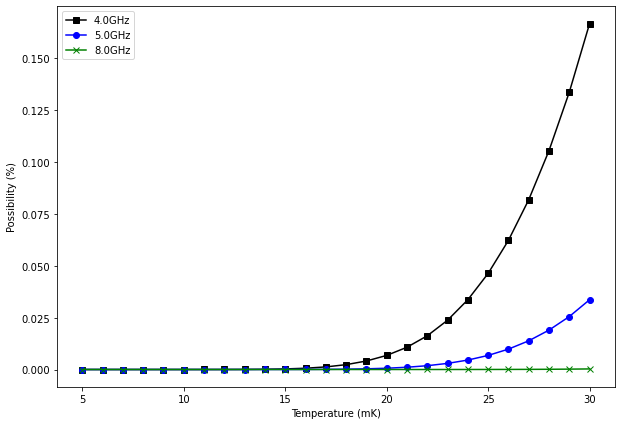

In [19]:
rst, _ = draw_possibility_on_frequencies([(4.0e9, 'k-s'), (5.0e9, 'b-o'), (8.0e9, 'g-x')])
plt.show()


In [20]:
rst


,temperature,4.0GHz,5.0GHz,8.0GHz
0,0.005,2.117004e-17,1.435992e-21,4.481707e-34
1,0.006,1.272823e-14,4.275236e-18,1.620079e-28
2,0.007,1.229706e-12,1.294946e-15,1.512176e-24
3,0.008,3.789449e-11,9.401997e-14,1.435992e-21
4,0.009,5.451450e-10,2.634147e-12,2.971831e-19
5,0.010,4.601091e-09,3.789449e-11,2.117004e-17
6,0.011,2.635012e-08,3.357208e-10,6.943288e-16
7,0.012,1.128195e-07,2.067664e-09,1.272823e-14
8,0.013,3.862035e-07,9.627645e-09,1.491530e-13
9,0.014,1.108922e-06,3.598535e-08,1.229706e-12


In [5]:
def draw_possibility_vs_frequencies_on_temperatures(
        temperatures: Iterable[Tuple[float, str]]
) -> [pd.DataFrame, Figure]:
    frequences = np.linspace(0.3e9, 3e9, 28, True)
    rst = pd.DataFrame()
    rst['frequences'] = frequences
    fig = plt.figure(figsize=(10, 7))
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Possibility (%)')
    for T, style in temperatures:
        possibilities = possibility_thermal_excitation(frequences, T)
        label = f'{T * 1e3}mK'
        plt.plot(frequences * 1e-9, possibilities * 100.0, style, label=label)
        rst[label] = possibilities
    plt.legend()
    return rst, fig


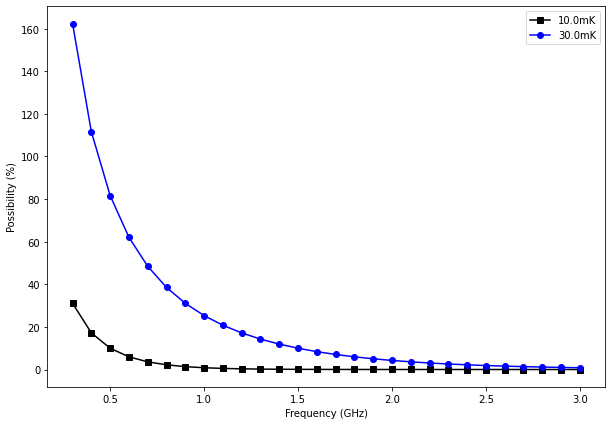

In [6]:
rst, _ = draw_possibility_vs_frequencies_on_temperatures([(10e-3, 'k-s'), (30e-3, 'b-o')])
plt.show()


In [7]:
rst


,frequences,10.0mK,30.0mK
0,3.000000e+08,3.105843e-01,1.623503
1,4.000000e+08,1.718540e-01,1.115711
2,5.000000e+08,9.981031e-02,0.816153
3,6.000000e+08,5.950191e-02,0.620616
4,7.000000e+08,3.600497e-02,0.484423
5,8.000000e+08,2.197932e-02,0.385221
6,9.000000e+08,1.348846e-02,0.310584
7,1.000000e+09,8.304373e-03,0.253050
8,1.100000e+09,5.122782e-03,0.207865
9,1.200000e+09,3.163954e-03,0.171854
